# Distributed Demographic + Genre Recommender — MovieLens 1M
**End-to-end pipeline**: PySpark → PyTorch (feature-based NCF/NeuMF) → TorchDistributor → Evaluation

The model predicts a rating from **user demographics** (Gender, Age, Occupation,
Zip region) and **movie genres** — no user/movie IDs — so it can recommend to a
brand-new user from a profile alone.

| Section | What happens |
|---|---|
| 1 | Distributed data pipeline (PySpark join + feature engineering) |
| 2 | Demographic + genre NCF/NeuMF architecture (PyTorch) |
| 3 | Distributed training via TorchDistributor |
| 4 | Model evaluation (PyTorch + Spark RegressionEvaluator) |
| 5 | Results visualisation |

In [2]:
# Verify the MovieLens 1M data files are present.
from pathlib import Path

DATA_DIR = 'data'
required = ['ratings.dat', 'users.dat', 'movies.dat']

for name in required:
    p = Path(DATA_DIR) / name
    if not p.exists():
        raise FileNotFoundError(
            f'{p} not found. Place the extracted MovieLens 1M files in the "{DATA_DIR}/" folder.'
        )
    print(f'Found {p}')

Using dataset: data/ratings.dat
Row count: 1,000,209


## Section 1: Distributed Data Pipeline

In [4]:
from section1_data_pipeline import build_pipeline

BATCH_SIZE = 1024

pipeline = build_pipeline(
    data_dir   = DATA_DIR,
    batch_size = BATCH_SIZE,
)

spark        = pipeline['spark']
train_loader = pipeline['train_loader']
test_loader  = pipeline['test_loader']
feature_dims = pipeline['feature_dims']
train_df     = pipeline['train_df']
test_df      = pipeline['test_df']

print(f'
Feature cardinalities: {feature_dims}')

[Spark] Session started  |  master=local[2]  |  cores=2
[Spark] Spark version: 4.0.2
[Data] Loaded 1,000,209 ratings from 'data/ratings.dat'
+-------+--------+------+---------+
|user_id|movie_id|rating|timestamp|
+-------+--------+------+---------+
|1      |1193    |5.0   |978300760|
|1      |661     |3.0   |978302109|
|1      |914     |3.0   |978301968|
|1      |3408    |4.0   |978300275|
|1      |2355    |5.0   |978824291|
+-------+--------+------+---------+
only showing top 5 rows
root
 |-- user_id: integer (nullable = true)
 |-- movie_id: integer (nullable = true)
 |-- rating: float (nullable = true)
 |-- timestamp: long (nullable = true)

[Data] Unique users: 6,040  |  Unique movies: 3,706
[Split] Train: 800,177 rows  |  Test: 200,032 rows  |  Ratio â‰ˆ 80.00% / 20.00%
[Dataset] Materialised 800,177 samples into tensors
[Dataset] Materialised 200,032 samples into tensors
[DataLoader] Train batches: 782  |  Test batches: 98  |  Batch size: 1024

Users: 6,040  |  Movies: 3,706


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


## Section 2: Architecture

In [5]:
import torch
from section2_model_architecture import build_model

MODEL_TYPE   = 'ncf'         # 'ncf' or 'neumf'
EMBED_DIM    = 32
HIDDEN_DIMS  = [128, 64]
DROPOUT      = 0.3

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# Sanity-check the architecture
model = build_model(MODEL_TYPE, feature_dims,
                    embed_dim=EMBED_DIM, hidden_dims=HIDDEN_DIMS, dropout=DROPOUT)
model.to(device)

# Quick forward pass with dummy demographic + genre features
with torch.no_grad():
    n = 4
    gender = torch.zeros(n, dtype=torch.long, device=device)
    age    = torch.zeros(n, dtype=torch.long, device=device)
    occ    = torch.zeros(n, dtype=torch.long, device=device)
    zipr   = torch.zeros(n, dtype=torch.long, device=device)
    genres = torch.zeros(n, feature_dims['num_genres'], device=device)
    out = model(gender, age, occ, zipr, genres)
    print(f'Sample output: {out.cpu().numpy()}')

del model  # free before distributed launch

Device: cpu

[Model] Built 'NCF'  | Users: 6,040  | Movies: 3,706  | Params: 698,881

NCFModel(
  (user_embedding): Embedding(6040, 64)
  (movie_embedding): Embedding(3706, 64)
  (mlp): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
  )
  (output_layer): Linear(in_features=64, out_features=1, bias=True)
)

[NCFModel] Trainable parameters: 698,881
Sample output: [1. 1. 1. 1.]


## Section 3: Distributed Training

In [11]:
import os, shutil
from section3_distributed_training import launch_distributed_training

# Force current directory into PYTHONPATH so distributed workers can find local modules
os.environ['PYTHONPATH'] = os.getcwd() + ':' + os.environ.get('PYTHONPATH', '')

NUM_EPOCHS   = 10
LR           = 1e-3
NUM_WORKERS  = 2       # number of TorchDistributor / DDP processes

train_result = launch_distributed_training(
    train_loader    = train_loader,
    feature_dims    = feature_dims,
    num_workers     = NUM_WORKERS,
    use_gpu         = torch.cuda.is_available(),
    model_type      = MODEL_TYPE,
    embed_dim       = EMBED_DIM,
    hidden_dims     = HIDDEN_DIMS,
    dropout         = DROPOUT,
    num_epochs      = NUM_EPOCHS,
    batch_size      = BATCH_SIZE,
    lr              = LR,
    checkpoint_dir  = 'checkpoints'
)

CHECKPOINT = train_result['best_checkpoint']
print(f'
Best checkpoint: {CHECKPOINT}')

# Copy the best checkpoint to the filename the FastAPI app loads.
shutil.copy(CHECKPOINT, 'model_for_streamlit.pt')
print('Copied to model_for_streamlit.pt (used by the FastAPI demo).')

[Launcher] Collecting training tensors for distribution â€¦


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
INFO:TorchDistributor:Started local training with 2 processes


[Launcher] Tensor shapes  users=(800177,)  movies=(800177,)  ratings=(800177,)
[Launcher] Starting TorchDistributor  num_processes=2  use_gpu=False


INFO:TorchDistributor:Finished local training with 2 processes



*****************************************
Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed.
*****************************************

[Distributed] world_size=2  backend=gloo  device=cpu

[Model] Built 'NCF'  | Users: 6,040  | Movies: 3,706  | Params: 698,881


[Model] Built 'NCF'  | Users: 6,040  | Movies: 3,706  | Params: 698,881

NCFModel(
  (user_embedding): Embedding(6040, 64)
  (movie_embedding): Embedding(3706, 64)
  (mlp): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(

## Section 4: Evaluation

In [ ]:
from section4_evaluation import run_evaluation

eval_results = run_evaluation(
    checkpoint_path = CHECKPOINT,
    test_loader     = test_loader,
    test_df         = test_df,
    use_spark_eval  = True,
)

## Section 5: Visualisation

Note: "eval_results" not found. Skipping test RMSE line.


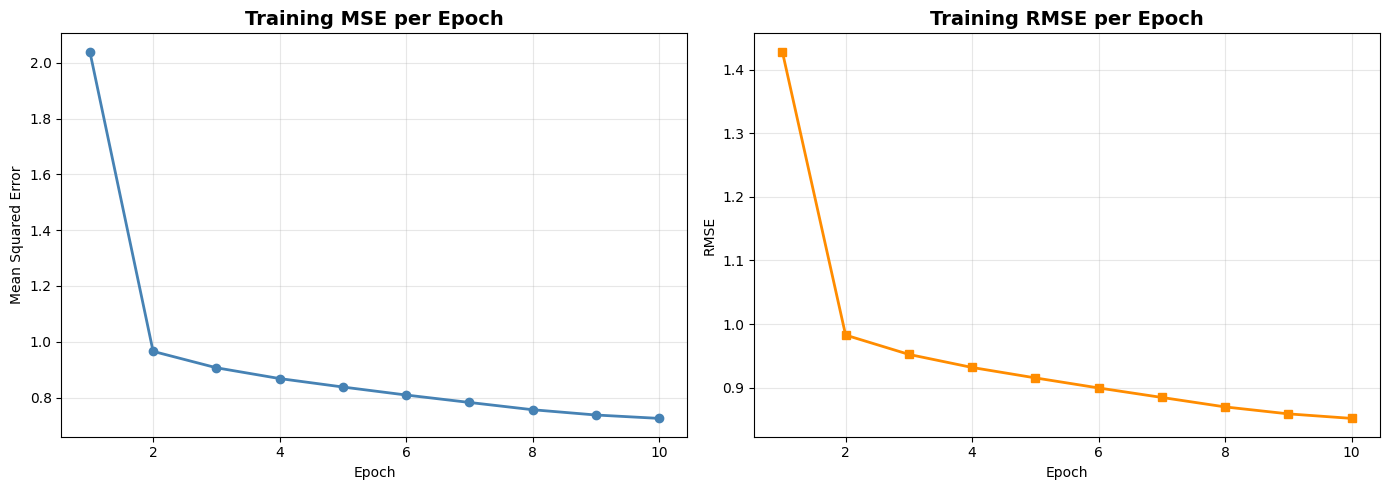

Plot saved to training_curves.png


In [13]:
import matplotlib.pyplot as plt
import numpy as np

epoch_losses = train_result.get('epoch_losses', [])
epochs       = list(range(1, len(epoch_losses) + 1))
rmse_per_epoch = [l ** 0.5 for l in epoch_losses]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# â”€â”€ MSE curve â”€â”€
axes[0].plot(epochs, epoch_losses, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Training MSE per Epoch', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Mean Squared Error')
axes[0].grid(True, alpha=0.3)

# â”€â”€ RMSE curve â”€â”€
axes[1].plot(epochs, rmse_per_epoch, marker='s', color='darkorange', linewidth=2)

# Check if eval_results exists in the global namespace to prevent NameError
if 'eval_results' in globals():
    test_rmse = eval_results.get('pytorch', {}).get('rmse', None)
    if test_rmse:
        axes[1].axhline(y=test_rmse, color='red', linestyle='--',
                        label=f'Test RMSE = {test_rmse:.4f}')
        axes[1].legend()
else:
    print('Note: "eval_results" not found. Skipping test RMSE line.')

axes[1].set_title('Training RMSE per Epoch', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('RMSE')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to training_curves.png')

In [14]:
# Stop Spark gracefully
spark.stop()
print('SparkSession stopped.')

SparkSession stopped.
